# 01 · Data exploration

Inspect the master table of 50 ms voice windows: coverage per clinical condition, feature distributions and inter-feature correlations.

> ⚠️ **Synthetic data.** This notebook runs on the small synthetic dataset from `scripts/make_sample_dataset.py`, so it renders and executes for anyone who clones the repo — no GPU and no private clinical data required. The *structure* of the analysis is identical to the thesis; only the numbers/figures differ. On the real MGH recordings the same cells reproduce the thesis results.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from voice_clustering.config import load_config

cfg = load_config()
features = cfg.acoustic_features
df = pd.read_parquet(cfg.paths.master_parquet)
print(f'{len(df):,} windows · {df.subject_id.nunique()} subjects')
df[['ts', 'subject_id', 'week', *features]].head()

32,000 windows · 3 subjects


,ts,subject_id,week,zcrall,normpeakall,spectralTiltall,LHratioall,level,cppall,freq,H1H2all
0,2012-01-01 09:00:00.000,PF001,Pre,0.143658,0.434779,-8.216257,13.614218,95.402397,12.344025,331.502974,1.138591
1,2012-01-01 09:00:00.050,PF001,Pre,0.040878,0.653399,-12.230439,21.813562,76.159584,18.424379,214.829164,6.085776
2,2012-01-01 09:00:00.100,PF001,Pre,0.158244,0.534412,-9.431685,13.903490,82.967461,11.257266,327.347458,1.781969
3,2012-01-01 09:00:00.150,PF001,Pre,0.164764,0.484867,-8.065667,13.021697,83.310730,10.684168,334.753890,2.021564
4,2012-01-01 09:00:00.200,PF001,Pre,0.047100,0.790628,-13.858580,19.999064,80.581389,19.708134,222.941043,6.012449


## Coverage by clinical condition

The cohort has three conditions: patients **Pre**- and **Post**-therapy and healthy **Control**s. Class balance matters because the pipeline fits UMAP/HDBSCAN on a sample stratified by `week`.

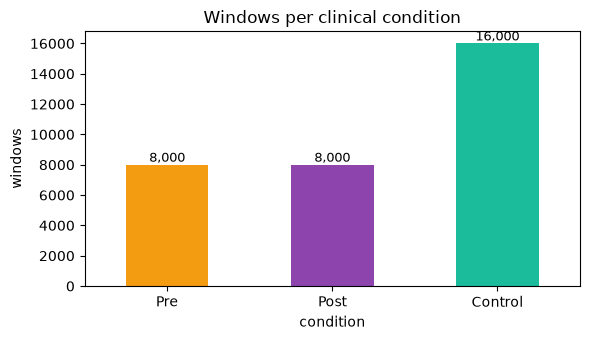

subject_id  week   
NF001       Control    8000
NF002       Control    8000
PF001       Post       8000
            Pre        8000
Name: windows, dtype: int64


In [2]:
counts = df['week'].value_counts().reindex(['Pre', 'Post', 'Control'])
ax = counts.plot.bar(color=['#F39C12', '#8E44AD', '#1ABC9C'], figsize=(6, 3.5), rot=0)
ax.set_ylabel('windows'); ax.set_xlabel('condition')
ax.set_title('Windows per clinical condition')
for i, v in enumerate(counts):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

print(df.groupby(['subject_id', 'week'], observed=True).size().rename('windows'))

## Feature distributions

The 8 acoustic features live on very different scales (e.g. `freq` in Hz vs `zcrall` in [0, 1]), which is exactly why the pipeline z-scores them before UMAP.

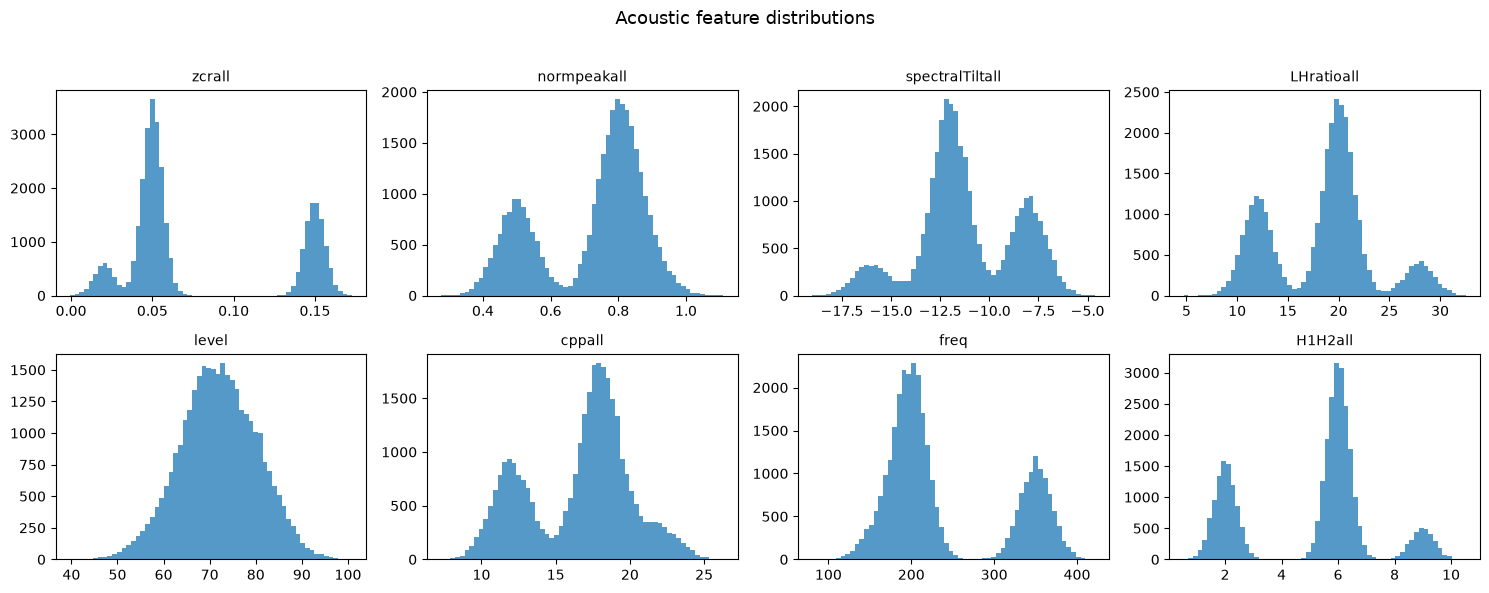

,mean,std,min,max
zcrall,0.077,0.049,-0.001,0.173
normpeakall,0.719,0.158,0.276,1.111
spectralTiltall,-11.205,2.564,-19.008,-4.637
LHratioall,18.410,5.025,4.717,32.545
level,71.992,8.347,39.661,100.902
cppall,16.605,3.490,7.279,26.298
freq,240.900,74.912,80.595,421.234
H1H2all,5.108,2.249,0.531,10.524


In [3]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, feat in zip(axes.ravel(), features):
    ax.hist(df[feat], bins=60, color='#2980B9', alpha=0.8)
    ax.set_title(feat, fontsize=10)
fig.suptitle('Acoustic feature distributions', fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.96)); plt.show()

df[features].describe().T[['mean', 'std', 'min', 'max']].round(3)

## Feature correlations

Highly correlated features are redundant for clustering. In the thesis this motivated dropping near-duplicate parameters (e.g. one of two CPP variants).

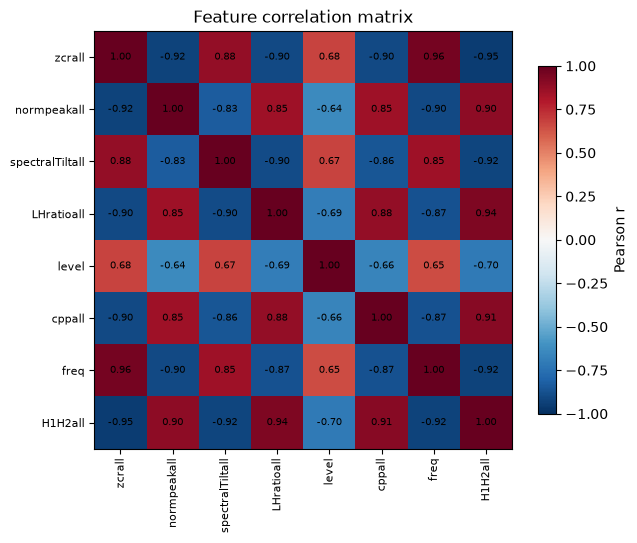

In [4]:
corr = df[features].corr()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(features))); ax.set_xticklabels(features, rotation=90, fontsize=8)
ax.set_yticks(range(len(features))); ax.set_yticklabels(features, fontsize=8)
for i in range(len(features)):
    for j in range(len(features)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                fontsize=7, color='black')
fig.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
ax.set_title('Feature correlation matrix'); plt.tight_layout(); plt.show()

### Takeaways

- The conditions are represented and can be balanced by `week`.
- Feature scales differ by orders of magnitude → standardization is required.
- Correlation structure guides which redundant parameters to drop.

Next: [`02_embedding_analysis.ipynb`](02_embedding_analysis.ipynb) runs UMAP + HDBSCAN and inspects the resulting clusters.